# Part 3: Analysis + Visualization

## Code Execution Order

1. first run `abs_raw_data_get.py`, which retrieves the ABS raw Excel file from the official website, and then `abs_raw_data_clean.py`, which cleans the workbook, exports the processed CSV files, and loads them into DuckDB. Next, run `nger_raw_data_get.py` to retrieve the yearly NGER raw CSV files, followed by `nger_raw_data_merge.py` to combine the multi-year files into one dataset, and then `nger_raw_date_clean.py` to standardize columns, clean values, and store the final NGER table in DuckDB. Finally, run `renewable_raw_data_get.py` to retrieve the renewable project CSV files, and `renewable_raw_date_clean.py` to clean, integrate, and load the renewable datasets into DuckDB.

2. data_cleaning_integration_augmentation.ipynb  
   - Performs data cleaning and integration, updating assignment_1.duckdb.

3. 3 Analysis+Visualisation.ipynb
   - Performs data exploration and generates visualisations using assignment_1.duckdb.

All scripts should be executed in the above order.

In [38]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [39]:
# connect database
con = duckdb.connect("assignment_1.duckdb")

# main analytical table
df = con.execute("""
SELECT *
FROM integrated_energy_state_year
ORDER BY state, year
""").fetchdf()

# project-level geocoded table
geo_df = con.execute("""
SELECT *
FROM renewable_projects_geocoded_nominatim_fallback
""").fetchdf()

con.close()

In [40]:
print(df.head())
print(df.columns)
print(geo_df.head())
print(geo_df.columns)

  state  year  total_generation_mwh  total_emissions_tco2e  total_businesses  \
0   ACT  2020               90253.0                 2979.0             29724   
1   ACT  2021               84427.0                 3786.0             31490   
2   ACT  2022              246566.0                 5287.0             33813   
3   ACT  2023              224556.0                 5621.0             35086   
4   NSW  2020            66062106.0             47477514.0            786246   

   small_businesses  renewable_project_count  total_renewable_capacity_mw  
0              8319                     <NA>                          NaN  
1              9995                     <NA>                          NaN  
2             10867                     <NA>                          NaN  
3             10908                     <NA>                          NaN  
4            225070                     <NA>                          NaN  
Index(['state', 'year', 'total_generation_mwh', 'total_emission

In [41]:
print(df.head)

<bound method NDFrame.head of    state  year  total_generation_mwh  total_emissions_tco2e  total_businesses  \
0    ACT  2020               90253.0                 2979.0             29724   
1    ACT  2021               84427.0                 3786.0             31490   
2    ACT  2022              246566.0                 5287.0             33813   
3    ACT  2023              224556.0                 5621.0             35086   
4    NSW  2020            66062106.0             47477514.0            786246   
5    NSW  2021            66059193.0             44495744.0            817603   
6    NSW  2022            65507505.0             43767780.0            854727   
7    NSW  2023            65088611.0             41640665.0            870951   
8     NT  2020             2154199.0              1290345.0             14547   
9     NT  2021             2204131.0              1228742.0             14943   
10    NT  2022             2233127.0              1218611.0             15731  

In [42]:
print(df.shape)

(32, 8)


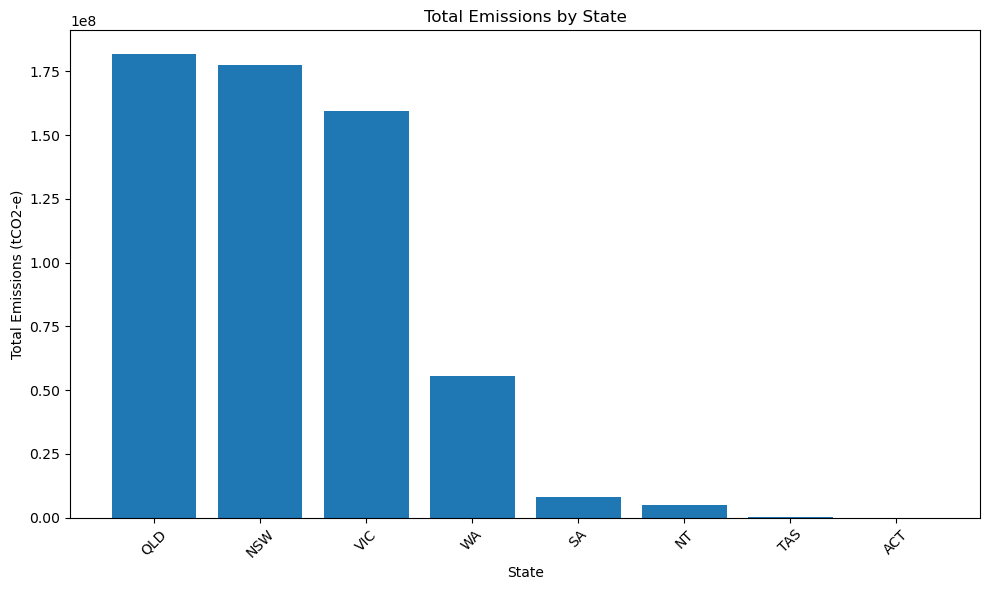

In [43]:
#graph1：Total Emissions by State
state_emissions = (
    df.groupby("state", as_index=False)["total_emissions_tco2e"]
    .sum()
    .sort_values("total_emissions_tco2e", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(state_emissions["state"], state_emissions["total_emissions_tco2e"])
plt.xlabel("State")
plt.ylabel("Total Emissions (tCO2-e)")
plt.title("Total Emissions by State")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig1_total_emissions_by_state.png", dpi=300, bbox_inches="tight")
plt.show()

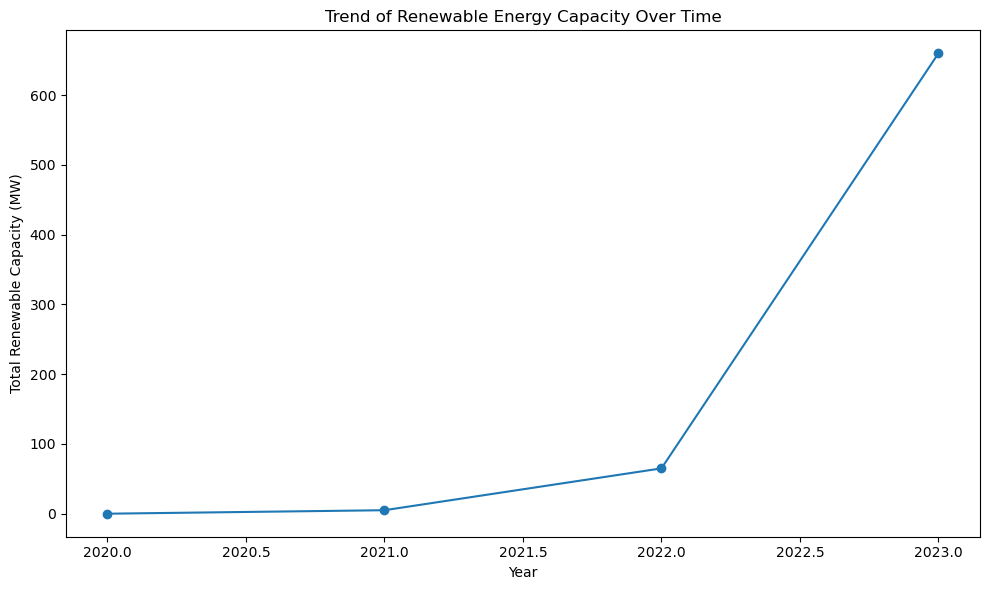

In [44]:
#graph2：Trend of Renewable Energy Capacity Over Time
renewable_trend = (
    df.groupby("year", as_index=False)["total_renewable_capacity_mw"]
    .sum()
    .sort_values("year")
)

plt.figure(figsize=(10, 6))
plt.plot(
    renewable_trend["year"],
    renewable_trend["total_renewable_capacity_mw"],
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Total Renewable Capacity (MW)")
plt.title("Trend of Renewable Energy Capacity Over Time")
plt.tight_layout()
plt.savefig("fig2_renewable_capacity_trend.png", dpi=300, bbox_inches="tight")
plt.show()

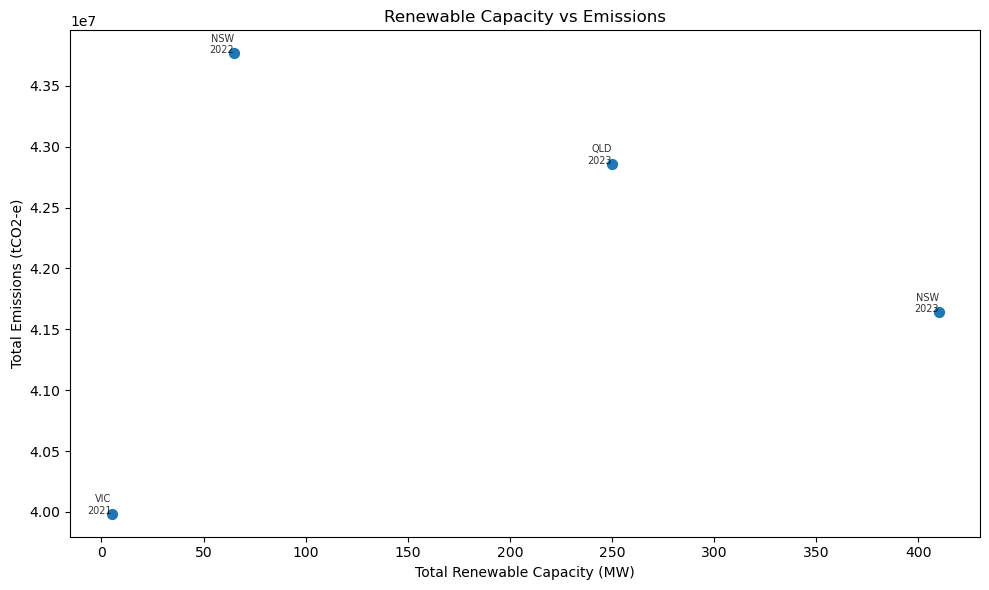

In [45]:
#graph3：renewable capacity vs emissions
plt.figure(figsize=(10, 6))
plt.scatter(
    df["total_renewable_capacity_mw"],
    df["total_emissions_tco2e"],
    s = 50
)
for i, state in enumerate(df["state"]):
    label = f"{df['state'].iloc[i]}\n{df['year'].iloc[i]}"
    plt.text(
        df["total_renewable_capacity_mw"].iloc[i],
        df["total_emissions_tco2e"].iloc[i],
        label,
        fontsize=7,
        ha='right', alpha=0.8
    )
plt.xlabel("Total Renewable Capacity (MW)")
plt.ylabel("Total Emissions (tCO2-e)")
plt.title("Renewable Capacity vs Emissions")
plt.tight_layout()
plt.savefig("fig3_renewable_vs_emissions.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
print(df["state"].value_counts())

state
ACT    4
NSW    4
NT     4
QLD    4
SA     4
TAS    4
VIC    4
WA     4
Name: count, dtype: int64


In [47]:
summary_by_state = df.groupby("state", as_index=False).agg({
    "total_emissions_tco2e": "mean",
    "total_renewable_capacity_mw": "mean",
    "total_generation_mwh": "mean",
    "total_businesses": "mean"
})

print(summary_by_state.sort_values("total_emissions_tco2e", ascending=False))

  state  total_emissions_tco2e  total_renewable_capacity_mw  \
3   QLD            45492614.75                        250.0   
1   NSW            44345425.75                        237.5   
6   VIC            39884541.25                          5.0   
7    WA            13889911.25                          NaN   
4    SA             2046517.75                          NaN   
2    NT             1250528.50                          NaN   
5   TAS               81060.00                          NaN   
0   ACT                4418.25                          NaN   

   total_generation_mwh  total_businesses  
3           60342902.00         471012.75  
1           65679353.75         832381.75  
6           46138813.50         679769.25  
7           24497830.75         234938.75  
4           11250651.75         152645.00  
2            2223096.75          15331.50  
5           10463366.25          41461.00  
0             161450.50          32528.25  


In [48]:
#graph4：map
geo_valid = geo_df.dropna(
    subset=["nominatim_fallback_latitude", "nominatim_fallback_longitude"]
).copy()

print("Geocoded rows:", len(geo_valid))
print("Total rows:", len(geo_df))
print("Match rate:", len(geo_valid) / len(geo_df))

Geocoded rows: 27
Total rows: 131
Match rate: 0.20610687022900764


In [49]:
#fig = px.scatter_geo(
#    geo_valid,
#    lat="nominatim_fallback_latitude",
#    lon="nominatim_fallback_longitude",
#    hover_name="project_name",
#    hover_data=["state", "capacity_mw", "fuel_source", "status"],
#    color="state",
#    title="Geocoded Renewable Energy Projects in Australia"
#)

#fig.write_html("fig4_geocoded_renewable_projects_map.html")
#fig.show()

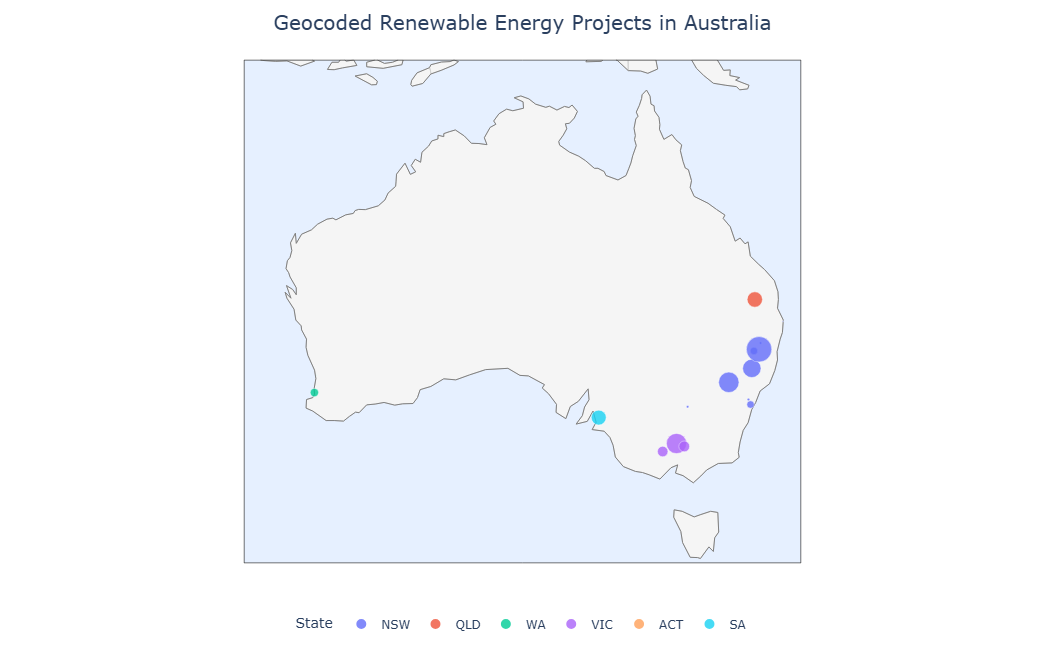

In [50]:
import plotly.express as px

geo_valid = geo_df.dropna(
    subset=["nominatim_fallback_latitude", "nominatim_fallback_longitude"]
).copy()

#Handle capacity shortage and prevent size issues
geo_valid["capacity_mw_plot"] = geo_valid["capacity_mw"].fillna(0)

fig = px.scatter_geo(
    geo_valid,
    lat="nominatim_fallback_latitude",
    lon="nominatim_fallback_longitude",
    color="state",
    size="capacity_mw_plot",
    size_max=18,
    hover_name="project_name",
    hover_data={
        "state": True,
        "capacity_mw": ":.1f",
        "fuel_source": True,
        "status": True,
        "nominatim_fallback_latitude": False,
        "nominatim_fallback_longitude": False,
        "capacity_mw_plot": False
    },
    title="Geocoded Renewable Energy Projects in Australia",
    projection="mercator"
)

fig.update_traces(
    marker=dict(
        opacity=0.8,
        line=dict(width=0.5, color="white")
    )
)

fig.update_layout(
    title=dict(
        text="Geocoded Renewable Energy Projects in Australia",
        x=0.5,
        xanchor="center",
        font=dict(size=20)
    ),
    legend=dict(
        title="State",
        orientation="h",
        yanchor="bottom",
        y=-0.15,
        xanchor="center",
        x=0.5
    ),
    margin=dict(l=20, r=20, t=60, b=20),
    height=650
)

fig.update_geos(
    scope="world",
    showcountries=True,
    countrycolor="lightgray",
    showcoastlines=True,
    coastlinecolor="gray",
    showland=True,
    landcolor="rgb(245,245,245)",
    showocean=True,
    oceancolor="rgb(230,240,255)",
    lataxis_range=[-45, -10],
    lonaxis_range=[110, 155]
)

fig.write_html("fig4_geocoded_renewable_projects_map.html")
fig.show()